In [30]:
import pandas as pd

In [31]:
df = pd.read_fwf('../datos/mjo/fmo.1x.txt', widths=[4, 3, 3, 3, 12, 12, 12],
                 names=['iyear', 'imonth', 'iday', 'ihour', 'PC1_coefficient', 'PC2_coefficient', 'PC1_PC2_amplitude'])
df['datetime'] = pd.to_datetime({
    'year': df['iyear'],
    'month': df['imonth'], 
    'day': df['iday'],
    'hour': df['ihour']
})
df.set_index('datetime', inplace=True)
df.drop(['iyear', 'imonth', 'iday', 'ihour'], axis=1, inplace=True)

In [32]:
def determinar_fase(omi1, omi2):
    """
    Ejemplo de lógica completa (debes adaptar los valores umbral)
    """
    # x=omi1
    # y=omi2
    x = omi2
    y = -omi1
    if x > 0:     
        if y > 0:  # cuadrante I
            if abs(x) > abs(y):
                return 5
            else:
                return 6
        else:      # cuadrante IV
            if abs(x) > abs(y):
                return 4
            else:
                return 3
    else: #(x<0)  
        if y > 0:  # cuadrante II
            if abs(x) > abs(y):
                return 8
            else:
                return 7
        else:      #cuadrante III
            if x>y:
                return 2
            else:
                return 1

In [33]:
df['fase']=df.apply(lambda row: determinar_fase(row['PC1_coefficient'], row['PC2_coefficient']), axis=1)

In [34]:
df2=pd.read_csv('../datos/mjo/WH.txt',header=None)


df2['datetime'] = pd.to_datetime({
    'year': df2[0],
    'month': df2[1], 
    'day': df2[2]
})
df2.set_index('datetime', inplace=True)

df2.drop([0, 1, 2, 3], axis=1, inplace=True)
# df2.head()

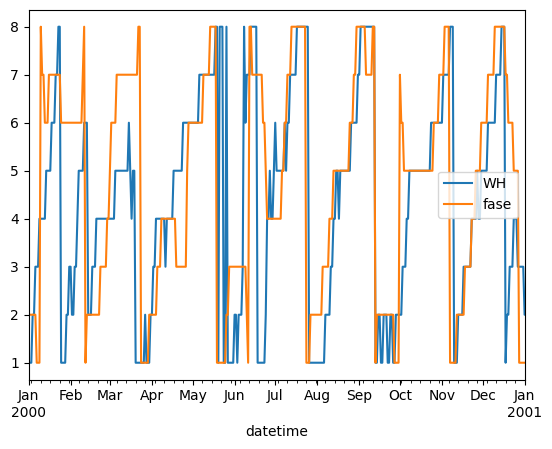

In [35]:
import matplotlib.pyplot as plt
df2[6].plot(label='WH')
df['fase'].plot()
ax=plt.gca()
ax.set_xlim(left='20000101',right='20010101')
ax.legend()

In [36]:
df.to_csv('../datos/mjo/fmo.1x.fase.csv')
df.to_pickle('../datos/mjo/fmo.1x.fase.pkl')

In [48]:
import numpy as np
df3 = pd.read_csv('../datos/mjo/serie_mjo.csv')
df3.head()

df3['datetime'] = pd.to_datetime({
    'year': df3['year'],
    'month': df3['month'], 
    'day': df3['day']
})
df3.set_index('datetime', inplace=True)
df3[df3['phase']==999]=np.nan

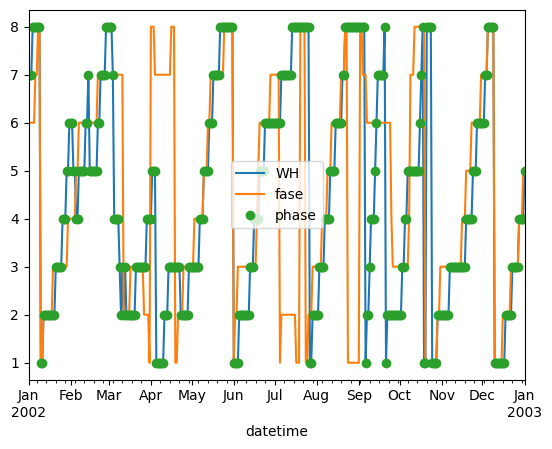

In [52]:
import matplotlib.pyplot as plt
df2[6].plot(label='WH')
df['fase'].plot()
df3['phase'].plot(style='o')
ax=plt.gca()
ax.set_xlim(left='20020101',right='20030101')
ax.legend()

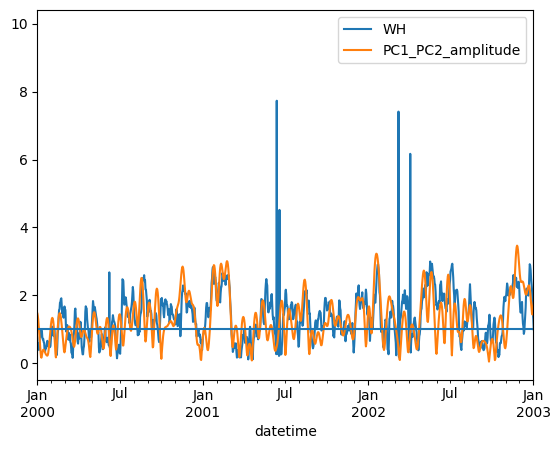

In [60]:
df2[7].plot(label='WH')
df['PC1_PC2_amplitude'].plot()

ax=plt.gca()
ax.set_xlim(left='20000101',right='20030101')
ax.hlines(xmin='20000101',xmax='20030101',y=1)
ax.legend()

In [53]:
df2.head()

,4,5,6,7
datetime,,,,
2000-01-01,-0.37285,-0.084006,1,0.382199
2000-01-02,-0.41773,-0.162100,1,0.448080
2000-01-03,-0.36624,-0.329840,1,0.492872
2000-01-04,-0.40185,-0.423020,2,0.583459
2000-01-05,-0.12710,-0.364840,2,0.386342


In [67]:
(df['PC1_PC2_amplitude'].loc['20000101':'20030101']>1).sum()

np.int64(651)

In [68]:
(df2[7].loc['20000101':'20030101']>1).sum()

np.int64(722)

In [72]:
((df2[7].loc['20000101':'20030101']>1) &  (df['PC1_PC2_amplitude'].loc['20000101':'20030101']>1)).sum()

np.int64(516)